In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, average_precision_score
from sklearn.feature_selection import RFECV, VarianceThreshold
from xgboost import XGBClassifier
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import shap
from flaml import AutoML

from src.preprocessing import load_data, merge_data, change_dtypes
from src.modeling import DefaultModel
pd.options.future.infer_string = False

In [2]:
df1, df2 = load_data(['data/interview homework file A.csv', 'data/interview homework file B.csv']) # Load the two datasets from the specified file paths
df = merge_data(df1, df2, on='ID') # Merge the two datasets on the 'ID' column after removing subcode '--xxx'
df = change_dtypes(df, str_cols=['ID'], date_cols=['APPLICATION_DATE']).sort_values('APPLICATION_DATE') # Change the data types of specified columns
df.reset_index(drop=True, inplace=True) # Reset the index of the DataFrame after sorting

#df['AGE_APP'] = df['AGE'] - (datetime.now().year - df['APPLICATION_DATE'].dt.year) # Calculate the age at the time of application by adjusting the current age with the time difference between now and the application date
#df['AGE_APP'] = np.clip(df['AGE'] - (datetime.now().year - df['APPLICATION_DATE'].dt.year), a_min=0, a_max=None).values
#df['AGE'] = np.clip(df['AGE'], 18, None)
#df['birth_year'] = np.clip(df['birth_year'], None, 2006)
df['AGE_APP'] = np.clip(df['APPLICATION_DATE'].dt.year - df['birth_year'], a_min=18, a_max=None)
#df['MAJORDRG_lag_concentration'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
#df['MINORDRG_lag_concentration'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)

df['INCOME_PER_DEP'] = df['MONTHLY_INCOME'] / (df['ADEPCNT'] + 1)
df['INCOME_LOG'] = np.log1p(df['MONTHLY_INCOME'])
df['ACADMOS_LOG'] = np.log1p(df['ACADMOS'])
df['MAJORDRG_MAX'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)
df['MINORDRG_MAX'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)
df['MAJORDRG_AVG_NONZERO'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
df['MINORDRG_AVG_NONZERO'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)

df.drop(columns=['MONTHLY_INCOME', 'ACADMOS'], inplace=True) # Drop zero variance columns and original MONTHLY_INCOME after feature engineering

"""bins = [-0.1, 25, 50, np.inf]
df['AGE_APP'] = pd.cut(df['AGE_APP'], bins=bins, labels=[0, 1, 2], right=False).astype(int)

df['APPLICATION_MONTH_SIN'] = np.sin(2 * np.pi * df['APPLICATION_DATE'].dt.month / 12)
df['APPLICATION_MONTH_COS'] = np.cos(2 * np.pi * df['APPLICATION_DATE'].dt.month / 12)

df['MAJORDRG_lag_concentration'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
df['MINORDRG_lag_concentration'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
df['INCOME_PER_DEP'] = df['MONTHLY_INCOME'] / (df['ADEPCNT'] + 1)
df['INCOME_LOG'] = np.log1p(df['MONTHLY_INCOME'])
df.drop(columns=['MONTHLY_INCOME'], inplace=True)

df['MAJORDRG_max'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)"""

cols_to_drop = ['birth_year', 'SPENDING', 'ANNUAL_INCOME', 'AGE']
df = df.drop(columns=cols_to_drop)

selector = VarianceThreshold(threshold=0.01)
selector.fit(df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT']))
low_variance_cols = df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT']).columns[~selector.get_support()]
print(f"Columns with low variance: {list(low_variance_cols)}")
df.drop(columns=low_variance_cols, inplace=True)

X = df.drop(columns=['CARDHLDR', 'ID', 'DEFAULT'])
y = df['DEFAULT']
approved_mask = df['CARDHLDR']

# time based split
cutoff_date = df[df['CARDHLDR']==1]['APPLICATION_DATE'].quantile(.9)

train_mask = (df['APPLICATION_DATE'] <= cutoff_date) & (approved_mask == 1)
test_mask = (df['APPLICATION_DATE'] > cutoff_date) & (approved_mask == 1)

X_train, y_train = X[train_mask].drop(columns=['APPLICATION_DATE']), y[train_mask]
X_test, y_test = X[test_mask].drop(columns=['APPLICATION_DATE']), y[test_mask]

#X_train, X_test, y_train, y_test = train_test_split(X[approved_mask==1].drop(columns=['APPLICATION_DATE']), y[approved_mask==1], test_size=0.1, random_state=42, stratify=y[approved_mask==1])

# drop columns with zero variance
zero_var_cols = X_train.columns[X_train.nunique() <= 1]
X_train = X_train.drop(columns=zero_var_cols)
X_test = X_test.drop(columns=zero_var_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

Columns with low variance: ['MAJORDRG_lag4', 'MAJORDRG_lag5', 'MAJORDRG_lag6', 'MAJORDRG_lag7', 'MAJORDRG_lag8', 'MAJORDRG_lag9', 'MAJORDRG_lag10', 'MAJORDRG_lag11', 'MINORDRG_lag2', 'MINORDRG_lag3', 'MINORDRG_lag4', 'MINORDRG_lag5', 'MINORDRG_lag6', 'MINORDRG_lag7', 'MINORDRG_lag8', 'MINORDRG_lag9', 'MINORDRG_lag10', 'MINORDRG_lag11']


In [3]:
# Initialize AutoML
automl = AutoML()

# Configure settings
settings = {
    "time_budget": 180,           
    "metric": 'roc_auc',
    "task": 'classification',    
    "estimator_list": ['xgboost'], 
    "early_stop": True,          
    "verbose": 3,
    "split_type": 'time',
}

# Run tuning
automl.fit(X_train=X_train, y_train=y_train, **settings)
y_pred_proba = automl.predict_proba(X_test)[:, 1]

# Get the best configuration
print('Best hyperparams:', automl.best_config)
print('Best ROC AUC:', 1-automl.best_loss)

print(f'TEST PR AUC: {average_precision_score(y_test, y_pred_proba):.2f}')
print(f'TEST ROC AUC: {roc_auc_score(y_test, y_pred_proba):.2f}')
print(f'TRAIN ROC AUC: {roc_auc_score(y_train, automl.predict_proba(X_train)[:, 1]):.2f}')
print(f'TRAIN PR AUC: {average_precision_score(y_train, automl.predict_proba(X_train)[:, 1]):.2f}')

[flaml.automl.logger: 04-06 15:55:04] {2375} INFO - task = classification
[flaml.automl.logger: 04-06 15:55:04] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-06 15:55:04] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 04-06 15:55:04] {2606} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 04-06 15:55:04] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 04-06 15:55:04] {3046} INFO - Estimated sufficient time budget=644s. Estimated necessary time budget=1s.
[flaml.automl.logger: 04-06 15:55:04] {3097} INFO -  at 0.1s,	estimator xgboost's best error=4.8311e-01,	best estimator xgboost's best error=4.8311e-01
[flaml.automl.logger: 04-06 15:55:04] {2911} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 04-06 15:55:04] {3097} INFO -  at 0.1s,	estimator xgboost's best error=4.7938e-01,	best estimator xgboost's best error=4.7938e-01
[flaml.automl.logger: 04-06 15:55:04] {2911} INFO - itera

{'n_estimators': 11, 'max_leaves': 4, 'min_child_weight': np.float64(0.4567087342556551), 'learning_rate': np.float64(0.05618208799909714), 'subsample': np.float64(0.6939870991308542), 'colsample_bylevel': np.float64(0.7183404127165985), 'colsample_bytree': np.float64(0.6155032423535861), 'reg_alpha': np.float64(0.009472099217616641), 'reg_lambda': np.float64(0.37062838338386866)}

In [4]:
automl.best_config

{'n_estimators': 4,
 'max_leaves': 4,
 'min_child_weight': np.float64(0.01209364751325945),
 'learning_rate': np.float64(0.047587486843348306),
 'subsample': np.float64(0.3447064707122859),
 'colsample_bylevel': np.float64(0.2676238062421719),
 'colsample_bytree': np.float64(0.8612071327608796),
 'reg_alpha': np.float64(0.05732223934879693),
 'reg_lambda': np.float64(460.51369619164205)}

In [14]:
# feature importance
importance = pd.Series(automl.model.estimator.feature_importances_, index=X_train.columns).sort_values(ascending=False)

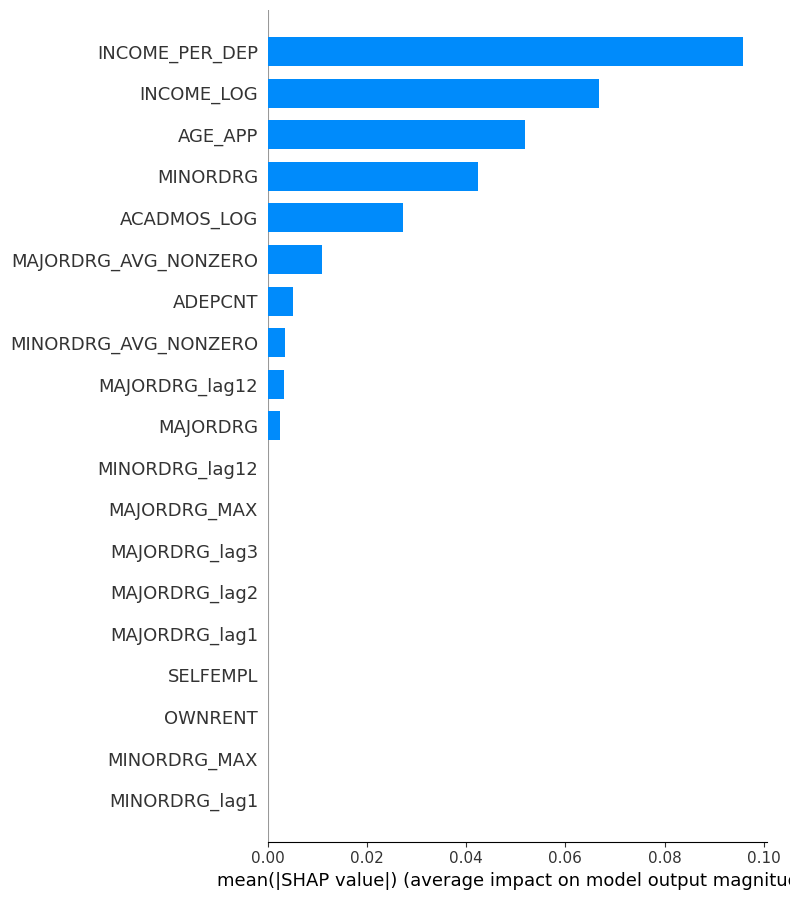

In [4]:
# feature importance
explainer = shap.TreeExplainer(automl.model.estimator)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap_values_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_values_df.apply(lambda x: abs(x).mean()).sort_values(ascending=False).head(20)
optimal_features = shap_values_df.apply(lambda x: abs(x).mean()).sort_values(ascending=False).head(8).index.tolist()

TEST PR AUC: 0.11,
TEST ROC AUC: 0.57,
TRAIN ROC AUC: 0.59,
TRAIN PR AUC: 0.14,

In [16]:
tscv = TimeSeriesSplit(n_splits=5)

model = DefaultModel(model_type='xgboost', **automl.best_config)

rfecv = RFECV(estimator=model._model_builder(), step=1, min_features_to_select=1, cv=tscv, scoring='roc_auc')
rfecv.fit(X_train, y_train)

optimal_features = X_train.columns[rfecv.support_]
optimal_features

Index(['MINORDRG_lag12', 'AGE_APP', 'INCOME_LOG', 'ACADMOS_LOG',
       'MAJORDRG_AVG_NONZERO'],
      dtype='object')

In [17]:
# Initialize AutoML
automl = AutoML()

# Configure settings
settings = {
    "time_budget": 60,           
    "metric": 'roc_auc',
    "task": 'classification',    
    "estimator_list": ['xgboost'], 
    "early_stop": True,          
    "verbose": 0,
    "split_type": 'time',         
}

# Run tuning
automl.fit(X_train=X_train[optimal_features], y_train=y_train, **settings)
best_model = automl.model
y_pred_proba = best_model.predict_proba(X_test[optimal_features])[:, 1]

# Get the best configuration
print('Best hyperparams:', automl.best_config)
print('Best ROC AUC:', 1-automl.best_loss)

print(f'TEST PR AUC: {average_precision_score(y_test, y_pred_proba):.2f}')
print(f'TEST ROC AUC: {roc_auc_score(y_test, y_pred_proba):.2f}')
print(f'TRAIN ROC AUC: {roc_auc_score(y_train, best_model.predict_proba(X_train[optimal_features])[:, 1]):.2f}')
print(f'TRAIN PR AUC: {average_precision_score(y_train, best_model.predict_proba(X_train[optimal_features])[:, 1]):.2f}')


Best hyperparams: {'n_estimators': 4, 'max_leaves': 48, 'min_child_weight': np.float64(0.4125765877543437), 'learning_rate': np.float64(0.008462095266322637), 'subsample': np.float64(0.953592825223878), 'colsample_bylevel': np.float64(0.7552688821217844), 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.0013162813316409054), 'reg_lambda': np.float64(0.34348492677481673)}
Best ROC AUC: 0.5382288186725657
TEST PR AUC: 0.13
TEST ROC AUC: 0.57
TRAIN ROC AUC: 0.68
TRAIN PR AUC: 0.24


In [18]:
automl.best_config

{'n_estimators': 4,
 'max_leaves': 48,
 'min_child_weight': np.float64(0.4125765877543437),
 'learning_rate': np.float64(0.008462095266322637),
 'subsample': np.float64(0.953592825223878),
 'colsample_bylevel': np.float64(0.7552688821217844),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.0013162813316409054),
 'reg_lambda': np.float64(0.34348492677481673)}